# Tutorial 1 — Solow model with population growth

Based on the python code written by John Finlay

This notebook will take us through numpy arrays and stepping an ODE forward in time to arrive at an approximate numerical solution.

## 1. The law of motion

Capital per worker rises when saving exceeds effective depreciation:

$$\dot k=g(k)=sAk^\alpha-(\delta+n)k.$$

The steady state solves $g(k^*)=0$. Before running the cell, say what happens to $k$ when it is below $k^*$.


### Import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Set parameters and define functions $f(k)$ and $g(k) = \dot k$ for output per worker and the law of motion.

In [11]:
ALPHA = 1 / 3
A = 1.0
s = 0.20
DELTA = 0.05
N = 0.01


def f(k):
    """Output per worker."""
    return A * k**ALPHA


def g(k):
    """
    The law of motion: how fast capital per worker is changing.

    This is the whole model. Everything below is a way of looking at it.
    """
    return s * f(k) - (DELTA + N) * k


### Analytical expression for the steady state $k^*$ and $g(k)$ evaluated at various points on $k$ grid

In [13]:
k_star = (s * A / (DELTA + N)) ** (1 / (1 - ALPHA))
print(f'k* = {k_star:.4f}; g(k*/2) = {g(k_star/2):.4f}; g(2k*) = {g(2*k_star):.4f}')


k* = 6.0858; g(k*/2) = 0.1072; g(2k*) = -0.2702


## 2. Visualising components of $k$ and phase line of $k$

At $k^*$, $sf(k)$ crosses $(\delta+n)k$. The vertical difference is $g(k)$. An array lets us evaluate each curve at many $k$ values with one expression.


In [ ]:
k_grid = np.linspace(0.01, 2.5 * k_star, 400)
print(k_grid[:5])

[0.01       0.04810656 0.08621311 0.12431967 0.16242622]
First five growth rates: [0.0425 0.0699 0.0832 0.0924 0.0994]


### Since $g(k)$ is the vertical gap 

In [ ]:
print('First five growth rates:', np.round(g(k_grid[:5]), 4))


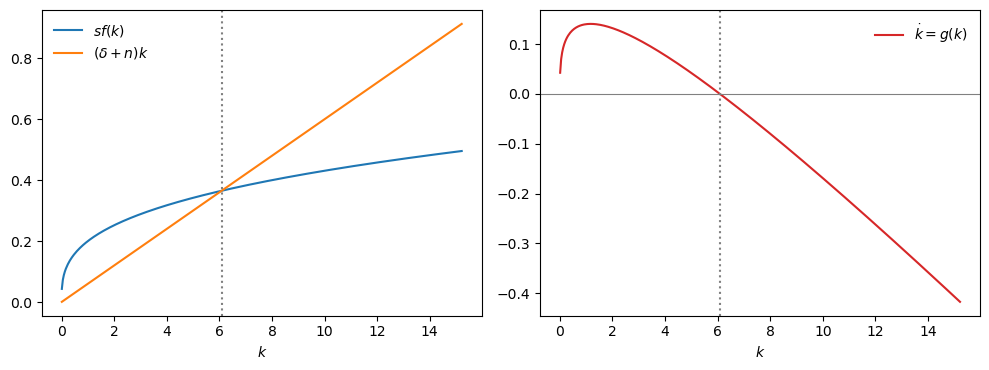

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(k_grid, S*f(k_grid), label=r'$sf(k)$')
axes[0].plot(k_grid, (DELTA+N)*k_grid, label=r'$(\delta+n)k$')
axes[1].plot(k_grid, g(k_grid), color='C3', label=r'$\dot k=g(k)$')
axes[1].axhline(0, color='0.5', lw=0.8)
for ax in axes:
    ax.axvline(k_star, color='0.5', ls=':')
    ax.set_xlabel('$k$')
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 3. Turn the differential equation into one small step

For a short interval $\Delta$, Euler's rule is

$$k_{t+\Delta}\approx k_t+\Delta g(k_t).$$

The right side uses the **current** $k_t$. Try one step by hand, then compare with Python.


In [6]:
dt = 0.1
k_now = k_star / 4
k_next = k_now + dt * g(k_now)
print(f'{k_now:.4f} -> {k_next:.4f}; change = {k_next-k_now:.5f}')


1.5215 -> 1.5353; change = 0.01387


## 4. Repeat the step

The loop stores the value *before* updating it. The returned arrays have matching time and capital entries.


In [7]:
def simulate(k0, T=200.0, dt=0.01):
    """Return the time grid and the path of k starting from k0."""
    t = np.arange(0.0, T + dt, dt)
    path = np.empty_like(t)
    k = k0
    for i in range(len(t)):
        path[i] = k
        k = k + dt * g(k)
    return t, path


In [8]:
time, capital = simulate(k_star/4, T=50, dt=0.1)
print('First five k values:', np.round(capital[:5], 4))
print('k(50) =', round(capital[-1], 4))


First five k values: [1.5215 1.5353 1.5492 1.563  1.5769]
k(50) = 5.3583


## 5. Test convergence

Run several initial conditions. Ask which curves rise, which fall, and why they approach the same level.


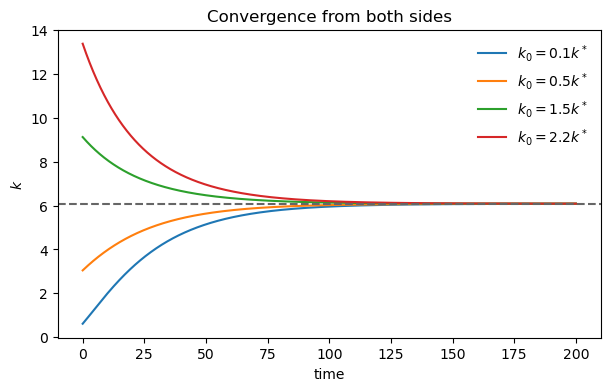

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for multiple in (0.1, 0.5, 1.5, 2.2):
    time, capital = simulate(multiple*k_star, T=200, dt=0.1)
    ax.plot(time, capital, label=rf'$k_0={multiple}k^*$')
ax.axhline(k_star, color='0.4', ls='--')
ax.set(xlabel='time', ylabel='$k$', title='Convergence from both sides')
ax.legend(frameon=False); plt.show()


## 6. Is the time step small enough?

The exact dynamic path is unknown. Halve $\Delta$ and check whether the quantity you care about changes appreciably. Here that quantity is $k(50)$, starting at $k^*/4$.


In [10]:
for step in (2.0, 1.0, 0.5, 0.1, 0.01):
    _, path = simulate(k_star/4, T=50, dt=step)
    print(f'dt={step:5g}: k(50)={path[-1]:.6f}')


dt=    2: k(50)=5.401816
dt=    1: k(50)=5.378793
dt=  0.5: k(50)=5.367396
dt=  0.1: k(50)=5.358331
dt= 0.01: k(50)=5.356298


**Pause and connect to PS1 1(g).** The problem set asks for paths from $k^*/4$ and $4k^*$ and a comparison with the local linear approximation. Change the first condition above, then use the rate of convergence from part (f).
